# Intro

Ophélie

# Imports

Cette section vous permet d'importer toutes les librairies utilisées dans ce Jupyter Notebook. Avant de commencer, il est préférable de créer un environnement virtuel, puis installer les librairies mentionnées dans le fichier "requirements.txt".

Commandes à exécuter (à la racine du projet) :
1. python -m venv .venv
2. .venv\Scripts\activate
3. pip install -r requirements.txt

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

import seaborn as sns
import scipy.stats as stats
from statsmodels.graphics.gofplots import qqplot
from statsmodels.graphics.gofplots import ProbPlot
import statsmodels.api as sm

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.linear_model import Lasso
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor

import optuna
from optuna.visualization import plot_slice

import mlflow
from mlflow.models import infer_signature

# Données

Description des données

Analysez les données en votre possession

Emettez des hypothèses sur les données qui possèdent le plus d’information selon vous. 

Ophélie

## Récupération et normalisation

Les jeux de données d'entraînement et de test sont chargés depuis les fichiers CSV fournis par Kaggle. La colonne `Id` est utilisée comme index car elle sert uniquement d’identifiant et ne contient aucune autre information utile.

In [2]:
train_raw = pd.read_csv('Data/train.csv', index_col = 'Id')
validation_raw = pd.read_csv('Data/test.csv', index_col = 'Id')

Visualisation de la distribution de la variable cible `SalePrice` à l’aide d’un histogramme avec une courbe de densité (KDE). Cette étape permet de détecter visuellement si la variable suit une distribution normale ou présente une asymétrie (skewness), ce qui peut influencer le choix des transformations futures.

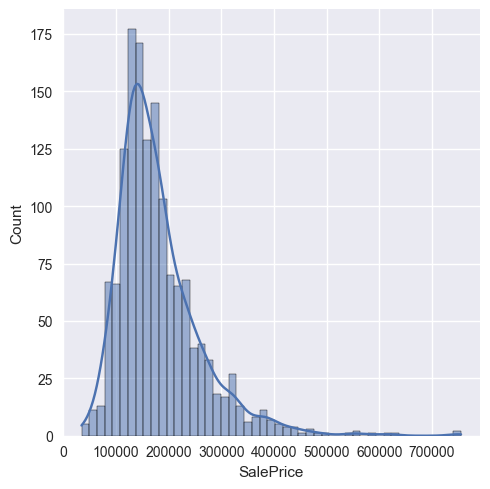

In [3]:
ax = sns.displot(data = train_raw['SalePrice'], kde=True)
plt.show()

Utilisation du test de Shapiro-Wilk pour évaluer statistiquement si la variable `SalePrice` suit une distribution normale.

**Hypothèse nulle (H₀)** : la variable suit une loi normale. Si la p-valeur < α (0.05), on rejette H₀ ⇒ `SalePrice` n’est pas normalement distribuée.

La normalité est une hypothèse souvent utile pour certains modèles ou certaines techniques de transformation, d’où l’intérêt de la tester formellement.

Le QQ-Plot (Quantile-Quantile plot) compare ensuite les quantiles de la distribution observée (`SalePrice`) à ceux d’une distribution normale théorique. Si les points suivent la ligne diagonale, cela suggère une distribution proche de la normale. S’ils dévient, cela confirme une asymétrie ou des valeurs extrêmes. Ce graphique complète le test de Shapiro-Wilk par une évaluation visuelle.

The assocated p-value is : 3.2061412312021656e-33
With a threshold α = 0.05, we reject the null hypothesis


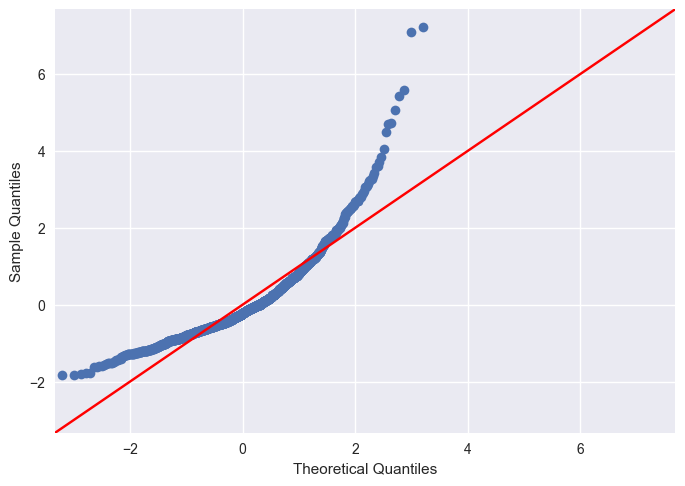

In [4]:
alpha = 0.05
W, p = stats.shapiro(train_raw['SalePrice'])

print('The assocated p-value is : ' + str(p))

if p < alpha : 
    print('With a threshold α = ' + str(alpha) + ', we reject the null hypothesis')
else : 
    print('With a threshold α = ' + str(alpha) + ', we fail to reject the null hypothesis')
    
qqplot(train_raw['SalePrice'], dist = stats.distributions.norm, fit = True, line = '45')
plt.show()

Le QQ-Plot montre une déviation importante des points par rapport à la diagonale (surtout dans les quantiles supérieurs), ce qui confirme une asymétrie à droite (right skew) typique des prix de vente. Cela implique que la variable cible `SalePrice` n’est pas normalement distribuée.

Nouvelle évaluation afin de savoir si la distribution suit une "log-normale" (si log(`SalePrice`) suit une normale). Ce deuxième QQ-Plot montre une bien meilleure linéarité, suggérant que la transformation logarithmique est pertinente pour réduire l’asymétrie.

Malgré cette correction, certains valeurs extrêmes émergent encore (sur la partie supérieure). Une analyse appronfondie de ces valeurs sera réalisée dans une prochaine section.

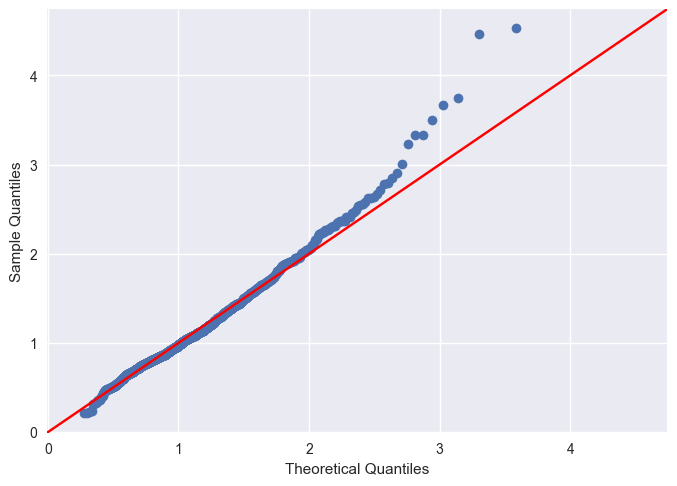

In [5]:
qqplot(train_raw['SalePrice'], dist = stats.distributions.lognorm, fit = True, line = '45')
plt.show()

La transformation `log1p(x)` (log(1 + x)) est utilisée pour rendre la distribution plus symétrique et proche de la normale pour notre variable cible. L’ajout de 1 avec log1p est une mesure de précaution pour éviter les erreurs log(0), même si dans ce jeu de données `SalePrice` est toujours > 0.

Un nouvel histogramme permet de confirmer visuellement que la distribution de la variable transformée est nettement plus symétrique. Cela appuie la validité de la transformation appliquée et justifie son utilisation.

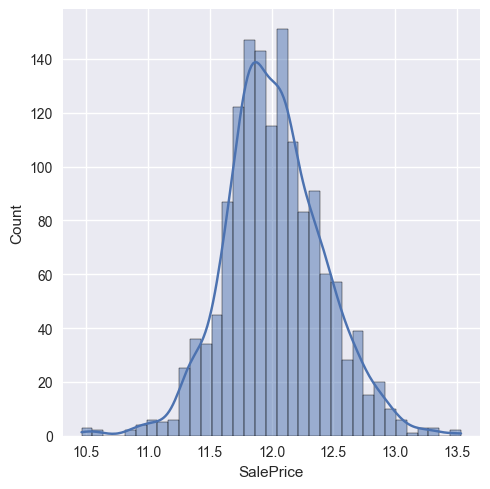

In [6]:
target = np.log1p(train_raw['SalePrice'])

# distribution plot
ax = sns.displot(data = target, kde=True)
plt.show()

## Traitement des données manquantes

La séparation des variables en trois catégories (qualitatives, quantitatives, et temporelles) est une étape importante pour appliquer des traitements appropriés à chaque type. Cette étape permettra un prétraitement cohérent par la suite.

Les jeux d'entraînement et de validation sont concaténés pour appliquer les mêmes traitements de nettoyage à l’ensemble des données. Cela évite de créer des incohérences entre les deux ensembles, notamment pour le traitement des valeurs manquantes.

In [7]:
qualitative = ['MSSubClass', 'MSZoning', 'Street', 'Alley', 'LotShape', 'LandContour', 'Utilities',
              'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
              'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'MasVnrType',
              'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure',
              'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
              'BsmtFullBath', 'BsmtHalfBath', 'FullBath', 'HalfBath', 'BedroomAbvGr', 'KitchenAbvGr', 'KitchenQual',
              'TotRmsAbvGrd', 'Functional', 'Fireplaces', 'FireplaceQu', 'GarageType', 'GarageFinish', 
              'GarageCars', 'GarageQual', 'GarageCond', 'PavedDrive', 'PoolQC', 'Fence', 'MiscFeature',
              'SaleType', 'SaleCondition', 'MoSold']

quantitative = ['LotFrontage', 'LotArea', 'OverallQual', 'OverallCond', 'MasVnrArea', 'BsmtFinSF1',  
               'BsmtFinSF2', 'BsmtUnfSF', 'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 
               'GarageArea', 'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 
               'PoolArea', 'MiscVal']

date = ['YearBuilt', 'YearRemodAdd', 'YrSold', 'GarageYrBlt']

In [8]:
data_raw = pd.concat([train_raw, validation_raw])

Avant de traiter les valeurs manquantes, il est essentiel de les identifier visuellement. Cette fonction permet :
- de détecter facilement quelles colonnes contiennent des données manquantes
- de quantifier l’importance du problème pour chaque variable

Toutes les valeurs manquantes ne doivent pas être traitées de la même façon. Il faut comprendre le sens de l'absence d'information.

Exemple :
- PoolArea = 0 → probablement pas de piscine (valeur informative)
- PoolQC = NaN → probablement une information manquante sur la qualité si la piscine existe

Dans ce contexte, on distingue deux grands cas :
- NaN = absence réelle
- NaN = donnée manquante

L’analyse visuelle des colonnes manquantes est donc une étape exploratoire clé pour décider de la meilleure stratégie d’imputation, en tenant compte du contexte métier de chaque variable.

In [9]:
# Plot des valeurs manquantes
def plot_missing(data):

    missing = data.isnull().sum()
    missing = missing[missing > 0]
    
    if missing.empty:
        print('No missing values')
    else :
        missing.sort_values(inplace=True)
        missing.plot.bar()
    
        plt.show()

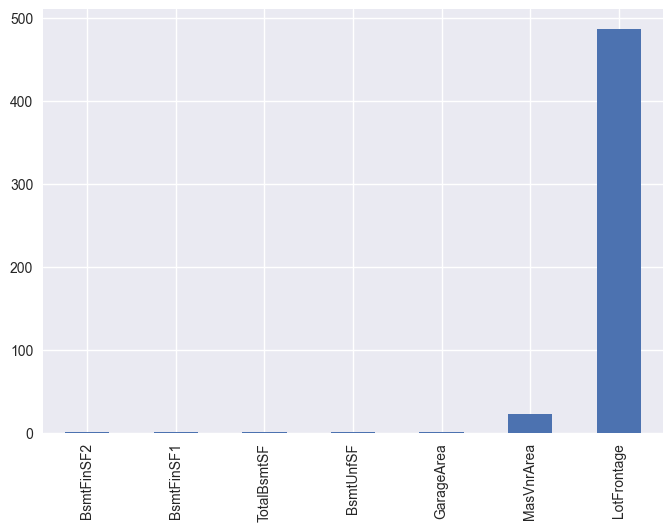

In [10]:
plot_missing(data_raw[quantitative])

Visualisation des données manquantes pour les variables qualitatives.

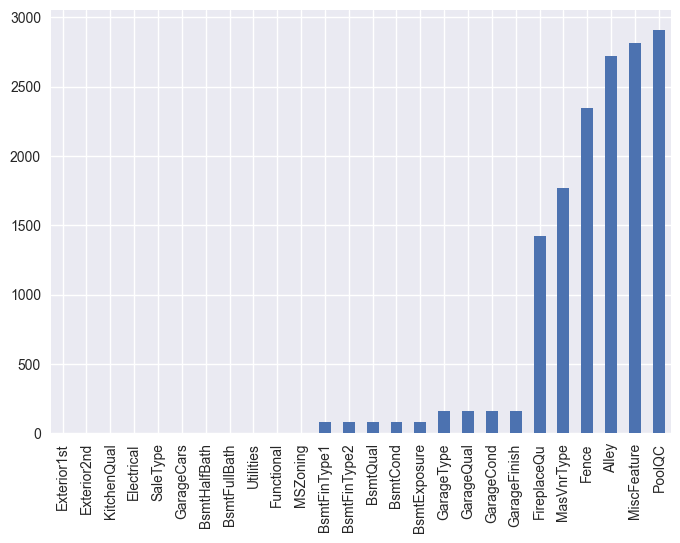

In [11]:
plot_missing(data_raw[qualitative])

Cette méthode générique permet de traiter efficacement et uniformément les valeurs manquantes dans les variables qualitatives ou quantitatives en les remplaçant par une constante prédéfinie (0, "None", "Unknown", etc.).

In [12]:
def fill_missing_with_constant(data, columns, constant):
    
    data_clean = data.copy()
    
    for c in columns :
        
        if data_clean[c].isnull().any():
            data_clean[c] = data_clean[c].fillna(constant)
    
    return data_clean

Visualisation des données manquantes pour les dates.

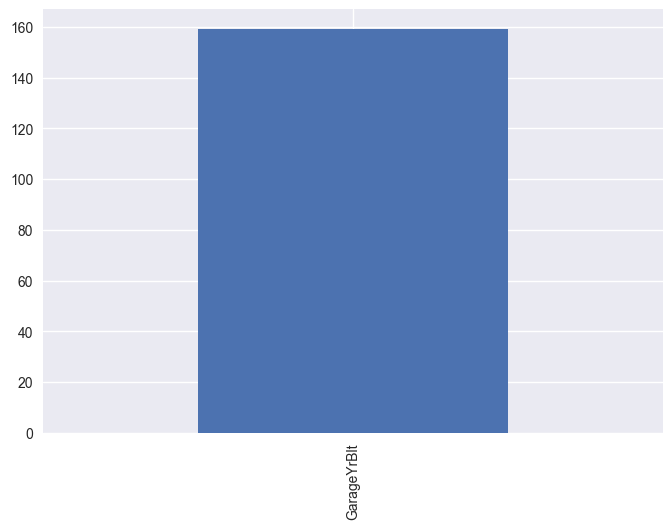

In [13]:
plot_missing(data_raw[date])

Certaines valeurs manquantes peuvent être déduites logiquement à partir d’autres colonnes du jeu de données.

C’est le cas, par exemple, de `GarageYrBlt`. S’il manque, il est raisonnable de supposer que le garage a été construit en même temps que la maison. On remplace donc la valeur manquante par `YearBuilt`. Cette méthode respecte la cohérence des données tout en évitant d’introduire des valeurs arbitraires.

In [14]:
def fill_missing_with_column(data, missing, column) :
    
    data_clean = data.copy()
    
    data_clean[missing] = np.where(data_clean[missing].isnull(), data_clean[column], data_clean[missing])
    
    return data_clean

## Transformation des dates

Les variables comme `YearBuilt`, `YearRemodAdd`, ou `GarageYrBlt` doivent être transformées en durées pour être exploitables par les modèles. On calcule ainsi :
- L'âge de la maison
- Temps écoulé depuis la rénovation
- Âge du garage

Cette transformation permet :
- d’extraire une information temporelle directement exploitable
- de standardiser les unités (toutes exprimées en années)

In [15]:
def compute_differences_to_year_sold(data) :
    
    data_clean = data.copy()
    
    data_clean['YearBuilt'] = data_clean['YrSold'] - data_clean['YearBuilt']
    data_clean['YearRemodAdd'] = data_clean['YrSold'] - data_clean['YearRemodAdd']
    data_clean['GarageYrBlt'] = data_clean['YrSold'] - data_clean['GarageYrBlt']
    
    return data_clean

## Nettoyage

La fonction `clean()` centralise toutes les étapes de prétraitement citées précédemment, en vue de les rendre cohérentes et prêtes pour la modélisation.

In [16]:
def clean(data) :
    
    data_clean = data.copy()
    
    # Traitement des valeurs manquantes
    data_clean = fill_missing_with_constant(data_clean, columns = quantitative, constant = 0)
    data_clean = fill_missing_with_constant(data_clean, columns = qualitative, constant = 'NA')
    data_clean = fill_missing_with_column(data_clean, missing = ['GarageYrBlt'], column = ['YearBuilt'])

    # Transformation des dates
    data_clean = compute_differences_to_year_sold(data_clean)
    
    return data_clean

# Modèle Baseline

**Section à supprimer ?**

Un modèle baseline est une première version simple d'un modèle de machine learning, utilisé comme point de comparaison pour évaluer les performances des modèles qui seront développés par la suite. Il permet d'établir un point de départ et ainsi identifier les apports des modèles plus complexes. Pour notre premier modèle, nous allons réaliser une régression linéaire simple.

JUSTIFIER

## Sélection des paramètres

Sélection basée sur la corrélation avec la méthode de Pearson. Pour ce faire, aucune transformation n’a été appliquée aux variables numériques, les variables catégorielles ont été encodées par la moyenne de la cible, et les variables de type date ont été transformées en nombre d’années depuis la vente.

Nous avons évité les variables trop liées entre elles grâce à la heatmap

[Introduire HeatMap]



Choix limité à 5 variables

Attention, d'un point de vue **interprétation**: les années ont une corrélation négative (plus c'est ancien, moins cela a de valeur)



**Variables**:
- OverallQual (l’évaluation globale de la qualité), Corrélation avec log(SalePrice) : +0.83 (la plus élevée)
- GrLivArea (surface habitable hors sous-sol, critère principal pour la taille du bien), Corrélation avec log(SalePrice) : +0.70
- TotalBsmtSF (surface totale du sous-sol, complète très bien GrLivArea en couvrant l’espace habitable invisible depuis les plans officiels,moins redondante que 1stFlrSF ou BsmtFinSF1), Corrélation avec log(SalePrice) : +0.62
- YearBuilt (l’ancienneté générale de la maison),capture toute l’infrastructure du bien. Des maisons anciennes dans des quartiers chers peuvent valoir plus qu’une maison récente dans un quartier médiocre. Corrélation négative avec log(SalePrice) : -0.59
- Neighborhood (quartier), variable la plus discriminante parmi toutes les catégorielles. Après son encodage en moyenne, corrélation de  +0.75 avec log(SalePrice)

**Utilité de chaque variable**:
- OverallQual: Qualité globale
- GrLivArea: Taille / Surface
- TotalBsmtSF: Surface complémentaire
- Neighborhood: Emplacement
- YearBuilt: Axe temporel

## Régression linéaire

Dans cette section, nous allons fit / adapter le modèle sur les données d'entraînement. Avant cela, nous devons séparer les données numériques, de celles catégoriques, afin d'apporter un traitement différent via des transformateurs. Ensuite un pipeline est créé pour regrouper les étapes à réaliser. Finalement, une cross-validation est réalisée afin de connaître le score moyen.

In [17]:
# Nettoayage des données
data_clean = clean(data_raw)

# Variables de base
base = ['OverallQual', 'GrLivArea', 'TotalBsmtSF', 'Neighborhood', 'YearBuilt']
x = data_clean[data_clean.index.isin(train_raw.index)][base].copy()
y = target.copy()

X_encoded = pd.get_dummies(x, columns=['Neighborhood'], drop_first=True)
X_array = sm.add_constant(X_encoded).astype(float)

# Création et entraînement du modèle de régression linéaire
model = sm.OLS(y, X_array)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.836
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     259.9
Date:                Fri, 13 Jun 2025   Prob (F-statistic):               0.00
Time:                        20:26:35   Log-Likelihood:                 586.90
No. Observations:                1460   AIC:                            -1116.
Df Residuals:                    1431   BIC:                            -962.5
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   10.9769 

### Assomptions du modèle

If we want to use a linear regression, we need to check certain assumptions, namely :

- Linearity of the link between the independant variables and the depedant variable
- Residuals are normally distributed around 0
- Homoscedasticity
- Residuals are free of structure
- Residuals are free of outliers

The following is a code I've found https://robert-alvarez.github.io/2018-06-04-diagnostic_plots/ which does this very well.

In [18]:
def graph(formula, x_range, label=None):
    """
    Fonction utilitaire pour tracer des lignes de référence (Cook’s distance)
    """
    x = x_range
    y = formula(x)
    plt.plot(x, y, label=label, lw=1, ls='--', color='red')

def diagnostic_plots(X, y, model_fit=None):
    """
    Génère les 4 diagnostics visuels classiques d’un modèle de régression linéaire :
    - Residuals vs Fitted
    - Normal Q-Q
    - Scale-Location
    - Residuals vs Leverage
    """

    # Refit du modèle si aucun modèle n’est passé
    if not model_fit:
        model_fit = sm.OLS(y, sm.add_constant(X)).fit()

    # Création d’un DataFrame pour faciliter les plots
    dataframe = pd.concat([X, y], axis=1)

    # Récupération des métriques
    model_fitted_y = model_fit.fittedvalues                    # Valeurs prédites
    model_residuals = model_fit.resid                          # Résidus
    model_norm_residuals = model_fit.get_influence().resid_studentized_internal  # Résidus standardisés
    model_norm_residuals_abs_sqrt = np.sqrt(np.abs(model_norm_residuals))
    model_abs_resid = np.abs(model_residuals)
    model_leverage = model_fit.get_influence().hat_matrix_diag
    model_cooks = model_fit.get_influence().cooks_distance[0]

    # === 1. Residuals vs Fitted ===
    plt.figure()
    sns.residplot(x=model_fitted_y, y=dataframe.columns[-1], data=dataframe,
                  lowess=True, scatter_kws={'alpha': 0.5},
                  line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
    plt.title('Residuals vs Fitted')
    plt.xlabel('Fitted values')
    plt.ylabel('Residuals')
    # Annotation des 3 résidus absolus les plus grands
    abs_resid_top_3 = model_abs_resid.sort_values(ascending=False)[:3]
    for i in abs_resid_top_3.index:
        plt.annotate(i, xy=(model_fitted_y[i], model_residuals[i]))

    # === 2. Normal Q-Q Plot ===
    QQ = ProbPlot(model_norm_residuals)
    qq_plot = QQ.qqplot(line='45', alpha=0.5, color='#4C72B0', lw=1)
    qq_plot.axes[0].set_title('Normal Q-Q')
    qq_plot.axes[0].set_xlabel('Theoretical Quantiles')
    qq_plot.axes[0].set_ylabel('Standardized Residuals')
    # Annotation des 3 valeurs les plus éloignées
    abs_norm_resid_top_3 = np.abs(model_norm_residuals).argsort()[-3:][::-1]
    for r, i in enumerate(abs_norm_resid_top_3):
        qq_plot.axes[0].annotate(i, xy=(QQ.theoretical_quantiles[r], model_norm_residuals[i]))

    # === 3. Scale-Location Plot ===
    plt.figure()
    plt.scatter(model_fitted_y, model_norm_residuals_abs_sqrt, alpha=0.5)
    sns.regplot(x=model_fitted_y, y=model_norm_residuals_abs_sqrt,
                scatter=False, ci=False, lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
    plt.title('Scale-Location')
    plt.xlabel('Fitted values')
    plt.ylabel('√|Standardized Residuals|')
    for i in abs_norm_resid_top_3:
        plt.annotate(i, xy=(model_fitted_y[i], model_norm_residuals_abs_sqrt[i]))

    # === 4. Residuals vs Leverage ===
    plt.figure()
    plt.scatter(model_leverage, model_norm_residuals, alpha=0.5)
    sns.regplot(x=model_leverage, y=model_norm_residuals,
                scatter=False, ci=False, lowess=True,
                line_kws={'color': 'red', 'lw': 1, 'alpha': 0.8})
    plt.title('Residuals vs Leverage')
    plt.xlabel('Leverage')
    plt.ylabel('Standardized Residuals')
    plt.xlim(0, max(model_leverage)+0.01)
    plt.ylim(-3, 5)
    # Annotation des points influents
    leverage_top_3 = np.argsort(model_cooks)[-3:][::-1]
    for i in leverage_top_3:
        plt.annotate(i, xy=(model_leverage[i], model_norm_residuals[i]))

    # === Lignes de Cook’s distance ===
    p = len(model_fit.params)  # nombre de paramètres
    graph(lambda x: np.sqrt((0.5 * p * (1 - x)) / x), np.linspace(0.001, max(model_leverage), 50), "Cook's 0.5")
    graph(lambda x: np.sqrt((1.0 * p * (1 - x)) / x), np.linspace(0.001, max(model_leverage), 50), "Cook's 1.0")
    plt.legend(loc='upper right')


c:\DataScience\data-science-project\.venv\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


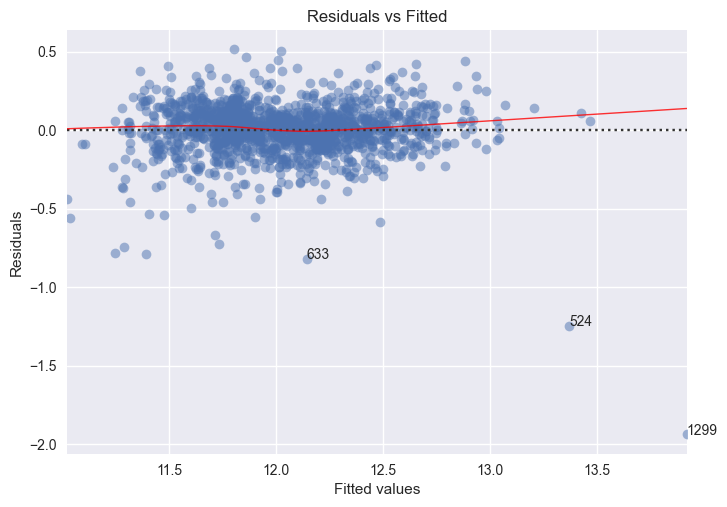

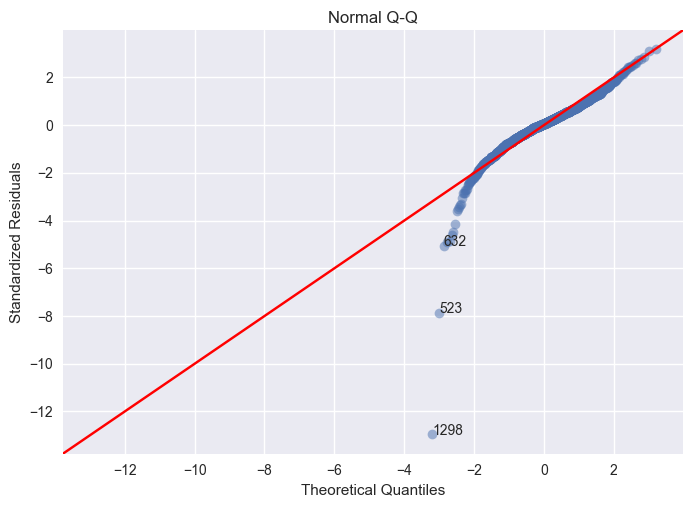

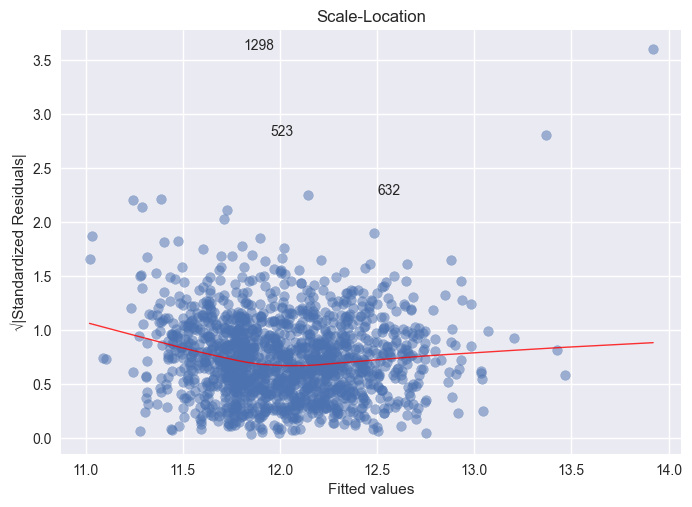

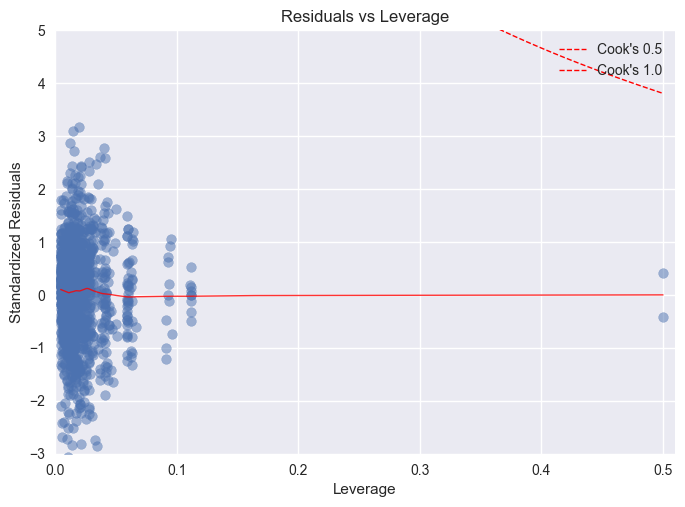

In [19]:
# Appel de la fonction de diagnostics
diagnostic_plots(X_encoded, y, model_fit=results)

### Vérification des hypothèses du modèle linéaire

Afin de s’assurer de la validité de notre régression linéaire, nous avons utilisé quatre graphiques diagnostics comme proposé ici: https://robert-alvarez.github.io/2018-06-04-diagnostic_plots/. 

#### 1. Residuals vs Fitted

Ce graphique montre les résidus en fonction des valeurs prédites. On attend une bande horizontale et aléatoire autour de 0.

La majorité des points sont bien centrés autour de zéro, sans motif clair. 
On observe quelques points atypiques (notamment l’observation `1299`) qui présentent un résidu négatif très fort, ce qui peut signaler une sous-estimation importante du prix de vente.


#### 2. Normal Q-Q Plot

Ce graphique teste si les résidus suivent une distribution normale.

Une déviation claire est visible aux extrémités, surtout dans la queue gauche (valeurs très négatives). Plusieurs points s’éloignent significativement de la ligne de référence. Cela indique une violation de l’hypothèse de normalité des résidus.

Cela suggère que le modèle a des difficultés à bien prédire certaines maisons très atypiques ou très peu chères. Nous allons effectuer une détection des outliers pour améliorer ce point.


#### 3. Scale-Location Plot

Ce graphique permet de vérifier l'homoscédasticité (constance de la variance des erreurs).

La variance semble globalement constante, sans structure évidente en éventail.

Quelques points (ex : `1298`, `523`) montrent une variabilité plus élevée à certaines prédictions. Cela mérite un examen ultérieur, mais ne remet pas fondamentalement en cause l’hypothèse d’homoscédasticité.

#### 4. Residuals vs Leverage (Cook's Distance)

Ce graphique détecte les points qui ont une forte influence sur les coefficients du modèle.

La grande majorité des observations ont un faible levier et des résidus modérés.
 
Un petit nombre de points s’approchent de la limite critique (leverage proche de 0.5), mais aucun ne dépasse franchement les seuils de Cook (0.5 ou 1.0).


### Identification des outliers 

L’analyse précédente a mis en évidence quelques points extrêmes, comme les observations `523` et `1298`, qui dévient fortement des tendances générales du modèle.

Certaines ventes ont été identifiées comme atypiques par https://jse.amstat.org/v19n3/decock/DataDocumentation.txt, notamment des biens avec une surface habitable (`GrLivArea`) supérieure à 4000 pieds carrés. Ces cas concernent souvent :
- des ventes partielles,
- ou des biens trop spécifiques pour être généralisables dans un modèle.

Nous avons combiné deux approches pour éliminer les points problématiques :

1. Le **critère métier** qui recommande de supprimer les maisons ayant plus de 4000 pieds carrés (`GrLivArea > 4000`). Ces ventes très atypiques ne sont pas représentatives du marché.

2. L’**analyse des résidus** via les graphiques de diagnostic, qui a permis d’identifier deux observations mal modélisées par la régression (`523`, `1298`). Bien qu’elles ne soient pas atypiques en taille, elles faussent fortement la distribution des résidus.

Les diagnostics montrent une amélioration de la distribution des erreurs, et un modèle plus stable.


In [20]:
# Affichage des features de base pour les deux points problématiques identifiés
x.loc[[523, 1298]]


,OverallQual,GrLivArea,TotalBsmtSF,Neighborhood,YearBuilt
Id,,,,,
523,6,1664,1004.0,BrkSide,59
1298,6,1072,547.0,Edwards,1


Index supprimés : [523, 524, 1298, 1299, 692, 1183]


,OverallQual,GrLivArea,TotalBsmtSF,YearBuilt,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,...,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker
Id,,,,,,,,,,,,,,,,,,,,,
523,6,1664,1004.0,59,False,False,True,False,False,False,...,False,False,False,False,False,False,False,False,False,False
524,10,4676,3138.0,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1298,6,1072,547.0,1,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1299,10,5642,6110.0,0,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
692,10,4316,2444.0,13,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False
1183,10,4476,2396.0,11,False,False,False,False,False,False,...,True,False,False,False,False,False,False,False,False,False


                            OLS Regression Results                            
Dep. Variable:              SalePrice   R-squared:                       0.862
Model:                            OLS   Adj. R-squared:                  0.859
Method:                 Least Squares   F-statistic:                     317.8
Date:                Fri, 13 Jun 2025   Prob (F-statistic):               0.00
Time:                        20:26:37   Log-Likelihood:                 722.70
No. Observations:                1454   AIC:                            -1387.
Df Residuals:                    1425   BIC:                            -1234.
Df Model:                          28                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   10.8755 

c:\DataScience\data-science-project\.venv\Lib\site-packages\statsmodels\graphics\gofplots.py:1041: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "b" (-> color=(0.0, 0.0, 1.0, 1)). The keyword argument will take precedence.
  ax.plot(x, y, fmt, **plot_style)


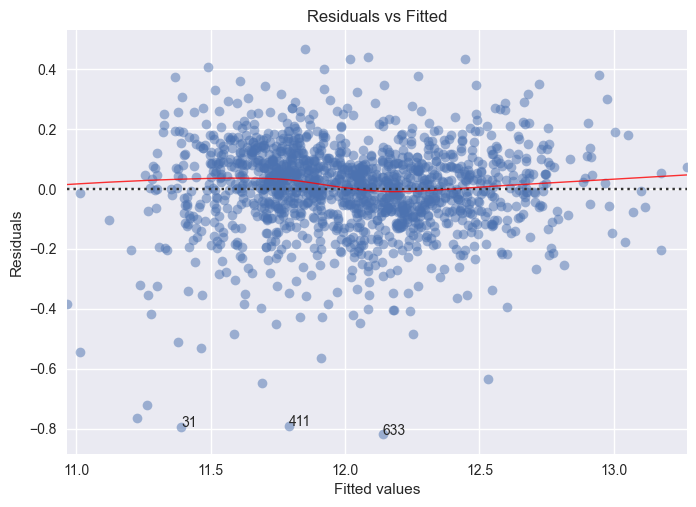

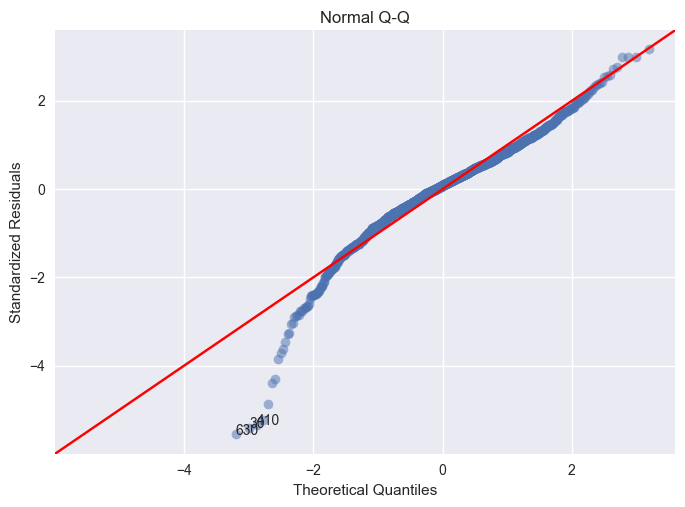

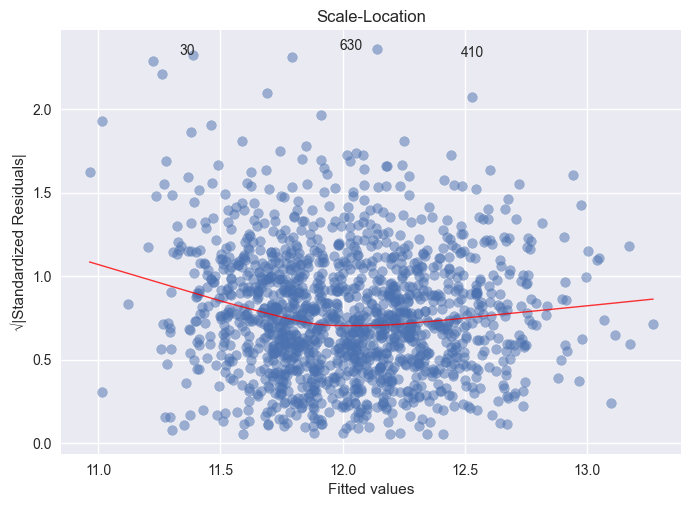

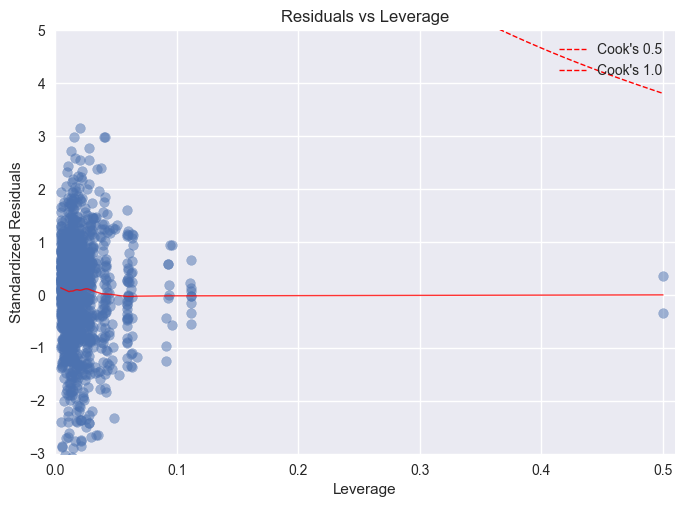

In [21]:
# Liste manuelle des index à supprimer (critère métier + résidus)
index_to_remove = X_encoded[(X_encoded['GrLivArea'] > 4000)].index.tolist()
index_to_remove += [523, 1298]

# Supprimer les doublons au cas où
index_to_remove = list(set(index_to_remove))

# Afficher les lignes concernées (facultatif)
print("Index supprimés :", index_to_remove)
display(X_encoded.loc[index_to_remove])

# Filtrer les données
X_cleaned = X_encoded.drop(index=index_to_remove)
y_cleaned = y.drop(index=index_to_remove)

# Convertir en float pour statsmodels
X_cleaned_float = X_cleaned.astype(float)
y_cleaned_float = y_cleaned.astype(float)

# Modèle linéaire réentraîné
model_cleaned = sm.OLS(y_cleaned_float, sm.add_constant(X_cleaned_float))
results_cleaned = model_cleaned.fit()
print(results_cleaned.summary())

# Graphiques diagnostics
diagnostic_plots(X_cleaned_float, y_cleaned_float, model_fit=results_cleaned)


## Prédiction et soumission sur Kaggle

Une fois le modèle fit / adapté, nous pouvons prédire les valeurs cibles manquantes dans notre jeu de données de validation. Attention à ne pas le faire sur le jeu de données d'entraînement ! Cela ne sert à rien, le résultat sera biaisé car nous avons entraîné le modèle sur ces mêmes données.

Ensuite, nous allons exporter les prédictions dans un fichier csv, qui sera soumis à Kaggle. Ce modèle Baseline obtient un score de 0.16482.

-> A vérifier mais je dirais que pour chaque résultat il faut comparer en se basant sur RMSLE. Je l'ai fait sur RMSE mais peut-être faux, le RMSLE c'est pour les données logarithmiques ?$

Réponse GPT : "RMSLE est utile si tu prédis directement les prix bruts. Mais ici, tu prédis déjà le log → donc utilise RMSE directement."

# Pipeline de prétraitement

In [22]:
# ----------------------
# 1. Fonction de transformation des dates en années
# ----------------------

def compute_relative_dates(df):
    df = df.copy()
    df['YearsSinceBuilt'] = df['YrSold'] - df['YearBuilt']
    df['YearsSinceRemod'] = df['YrSold'] - df['YearRemodAdd']
    df['YearsSinceGarage'] = df['YrSold'] - df['GarageYrBlt'].fillna(df['YearBuilt'])
    return df[['YearsSinceBuilt', 'YearsSinceRemod', 'YearsSinceGarage']]


# Transformer scikit-learn compatible avec la nouvelle fonction date
date_transformer = Pipeline(steps=[
    ('relativedates', FunctionTransformer(compute_relative_dates, validate=False))
])

# ----------------------
# 2. Pipeline pour les colonnes numériques
# ----------------------

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),     # remplace les NaN par la moyenne
    ('scaler', StandardScaler())                     # normalise (utile pour modèles linéaires par exemple)
])

# ----------------------
# 3. Pipeline pour les colonnes catégorielles
# ----------------------

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),  # ajoute une vraie catégorie "Missing"
    ('encoder', OneHotEncoder(handle_unknown='ignore'))                     # transforme en colonnes binaires, ignore les inconnues au test
])

# ----------------------
# 4. Assemblage global via ColumnTransformer
# ----------------------

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, quantitative),
    ('cat', categorical_transformer, qualitative),
    ('dates', date_transformer, date)
], remainder='drop')  

# ----------------------
# 5. Préparation des données
# ----------------------

# Séparation train / test dans les données brutes
X_train = data_raw.loc[train_raw.index]
X_test = data_raw.loc[validation_raw.index]
y_train = target.copy()

# Suppression des outliers dans X_train et y_train
outliers_idx = train_raw.index[
    (train_raw['GrLivArea'] > 4000) |
    (train_raw.index.isin([523, 1298]))
]

X_train = X_train.drop(index=outliers_idx)
y_train = y_train.drop(index=outliers_idx)

# ----------------------
# 6. Pipeline de prétraitement finale
# ----------------------

preprocessing_pipeline = Pipeline([
    ('preprocessor', preprocessor)
])

preprocessing_pipeline

print(f"Nombre d'observations avant suppression des outliers : {train_raw.shape[0]}")
print(f"Nombre d'observations après suppression : {X_train.shape[0]}")
print(f"Outliers supprimés : {len(outliers_idx)}")


Nombre d'observations avant suppression des outliers : 1460
Nombre d'observations après suppression : 1454
Outliers supprimés : 6


# Modèle 1 - Random Forest

In [23]:
# ----------------------
# Méthode pour optimiser le modèle RandomForest
# ----------------------
def random_forest_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 500, 1200),
        'max_depth': trial.suggest_int('max_depth', 10, 40, log=True),
        'min_samples_split': trial.suggest_float('min_samples_split', 1e-5, 0.01, log=True),
        'min_samples_leaf': trial.suggest_float('min_samples_leaf', 1e-6, 1e-4, log=True),
        'max_features': trial.suggest_float('max_features', 0.1, 0.8)
    }
    model = RandomForestRegressor(**params, random_state=42, n_jobs=-1)
    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return -scores.mean()

Pour ce modèle `Random Forest Regressor`, différents tests ont été réalisés afin de sélectioner les meilleures plages d'hyperparamètres. Voici une justification pour chaque paramètre :
 - **n_estimators** : plus le nombre d'arbres est élevé, plus le modèle est stable. Cependant, ils ont été limités à 1000 afin d'éviter un temps d'entrainement trop conséquent.
 - **max_depth** : Une bonne profondeur est indispensable pour éviter l'overfitting et l'underfitting. Une taille trop petite est trop restrictive et au dela de 40 est peu utile pour un data set moyen comme celui-ci (environ 1400 lignes)
 - **min_samples_split** : En augmentant cette valeur, il est possible d'éviter l'overfitting. L'objectif est donc de laisser une certaine liberté au modèle, afin qu'il puisse avoir des splits profonds (2) ou plus restreints (20).
 - **min_samples_leaf** : Pour cet hyperparamètre, une certaine liberté est donnée également. Le fait d'avoir une valeur petite (1) peut rendre le modèle sensible au bruit, il faut donc avoir une valeur maximale (10) cohérente pour forcer des règles plus générales.
 - **max_features** : Cette valeur permet de réduire le nombre de features candidates pour chaque noeud, le but est donc de donner trois façons de faire plus ou moins restrictives pour permettre de tester des cas différents.

# Modèle 2 - Régression Lasso

In [24]:
# ----------------------
# Méthode pour optimiser le modèle Lasso
# ----------------------
def lasso_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    alpha = trial.suggest_float('alpha', 0.0005, 0.0008, log=True)
    model = Lasso(alpha=alpha, max_iter=10000, random_state=42)
    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])
    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    return -scores.mean()

Pour modèle, le seul hyperparamètres intéressant est l'alpha. Ce dernier contrôle la force de la régularisation L1 appliquée. Un alpha faible donne un modèle très flexible, qui risque de surajuster. Alors qu'un grand alpha offre une régularisation forte et donc un modèle très rigide (car de nombreux coefficients seront faibles). Comme nous avons un data set moyen avec beaucoup de features (365), un risque de surajustement existe. Ici la borne supérieure (10) nous permet de ne pas avoir un modèle trop rigide et sous-ajusté. 

Nous sommes conscients que certains modèles (comme Lasso ou Ridge) peuvent présenter un `second sweet spot` pour des valeurs extrêmes d’hyperparamètres, mais cette hypothèse ne sera pas explorée dans le cadre de ce projet.

# Modèle 3 - Decision Tree

In [25]:
# ----------------------
# Méthode pour optimiser le modèle DecisionTree
# ----------------------
def decision_tree_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    
    params = {
        'max_depth': trial.suggest_int('max_depth', 10, 30),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 10, 15),
        'max_features': trial.suggest_categorical('max_features', [None,'sqrt'] )
    }

    model = DecisionTreeRegressor(**params, random_state=42)

    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    return -scores.mean()

# Modèle 4 - XGBoost

In [26]:
# ----------------------
# Méthode pour optimiser le modèle XGBoost
# ----------------------
def xgboost_objective(trial, preprocessing_pipeline, X, y, cv, scoring):
    params = {
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'n_estimators': trial.suggest_int('n_estimators', 500, 1200),
        'max_depth': trial.suggest_int('max_depth', 5, 20),
        'min_child_weight': trial.suggest_int('min_child_weight', 5, 10),
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma': trial.suggest_float('gamma', 0, 0.3),
        'alpha': trial.suggest_float('alpha', 1e-6, 100, log=True),
        'lambda': trial.suggest_float('lambda', 1e-6, 100, log=True)
    }

    model = XGBRegressor(**params, objective='reg:squarederror', random_state=42, n_jobs=-1)

    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)

    return -scores.mean()

# Optimisation des modèles

In [27]:
def evaluate_and_optimize_models(model_configs, X, y, preprocessing_pipeline, cv=5, n_trials=30, scoring='neg_root_mean_squared_error'):
    """
    Optimise les modèles avec Optuna puis évalue leur performance via validation croisée.

    Paramètres:
    - model_configs: dict[str, callable], nom du modèle -> fonction objective(trial, pipeline, X, y)
    - X, y: données d'entrée brutes (non transformées)
    - preprocessing_pipeline: pipeline de prétraitement à injecter dans chaque modèle
    - cv: nombre de folds pour la cross-validation
    - n_trials: nombre d’essais pour Optuna
    - scoring: métrique (RMSE négatif par défaut)

    Retourne : dict avec les résultats RMSE moyens + std
    """

    results = {}

    for name, objective_func in model_configs.items():
        print(f"\nOptimisation pour : {name}")

        def wrapped_objective(trial):
            return objective_func(trial, preprocessing_pipeline, X, y, cv, scoring)

        study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=42), study_name=name)
        study.optimize(wrapped_objective, n_trials=n_trials, show_progress_bar=True)

        best_score = study.best_value
        best_params = study.best_params
        print(f"✅ {name} | RMSE = {best_score:.4f} | Paramètres: {best_params}")
        print("------------------------------------")

        results[name] = (best_score, best_params, study)
    
    # Affichage graphique
    names = list(results.keys())
    means = [results[name][0] for name in names]

    plt.figure(figsize=(10, 5))
    plt.bar(names, means)
    plt.ylabel("Meilleur RMSE (CV)")
    plt.title("Comparaison des modèles optimisés")
    plt.xticks(rotation=45)
    plt.grid(axis='y')
    plt.tight_layout()
    plt.show()

    return results

[I 2025-06-13 20:26:39,433] A new study created in memory with name: Lasso



Optimisation pour : Lasso


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-06-13 20:26:43,818] Trial 0 finished with value: 0.11131778513303699 and parameters: {'alpha': 0.0005962400256413869}. Best is trial 0 with value: 0.11131778513303699.
[I 2025-06-13 20:26:46,275] Trial 1 finished with value: 0.11167746620691725 and parameters: {'alpha': 0.0007816814251404263}. Best is trial 0 with value: 0.11131778513303699.
[I 2025-06-13 20:26:48,316] Trial 2 finished with value: 0.11143348283729879 and parameters: {'alpha': 0.000705317395342491}. Best is trial 0 with value: 0.11131778513303699.
[I 2025-06-13 20:26:48,665] Trial 3 finished with value: 0.11135695519601355 and parameters: {'alpha': 0.0006624729710901097}. Best is trial 0 with value: 0.11131778513303699.
[I 2025-06-13 20:26:49,096] Trial 4 finished with value: 0.11130617560795378 and parameters: {'alpha': 0.0005380424313112669}. Best is trial 4 with value: 0.11130617560795378.
[I 2025-06-13 20:26:49,549] Trial 5 finished with value: 0.11130617816582906 and parameters: {'alpha': 0.0005380363318076

[I 2025-06-13 20:27:27,664] A new study created in memory with name: Decision Tree


...

[I 2025-06-13 20:27:27,919] Trial 0 finished with value: 0.18559629829153557 and parameters: {'max_depth': 17, 'min_samples_split': 20, 'min_samples_leaf': 14, 'max_features': None}. Best is trial 0 with value: 0.18559629829153557.
[I 2025-06-13 20:27:28,084] Trial 1 finished with value: 0.2235844110730131 and parameters: {'max_depth': 13, 'min_samples_split': 3, 'min_samples_leaf': 15, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.18559629829153557.
[I 2025-06-13 20:27:28,288] Trial 2 finished with value: 0.1856331210933349 and parameters: {'max_depth': 10, 'min_samples_split': 20, 'min_samples_leaf': 14, 'max_features': None}. Best is trial 0 with value: 0.18559629829153557.
[I 2025-06-13 20:27:28,482] Trial 3 finished with value: 0.1859065720517069 and parameters: {'max_depth': 13, 'min_samples_split': 7, 'min_samples_leaf': 13, 'max_features': None}. Best is trial 0 with value: 0.18559629829153557.
[I 2025-06-13 20:27:28,626] Trial 4 finished with value: 0.2201464539191530

[I 2025-06-13 20:27:46,757] A new study created in memory with name: XGBoost


[I 2025-06-13 20:27:46,559] Trial 98 finished with value: 0.22682634635994744 and parameters: {'max_depth': 18, 'min_samples_split': 20, 'min_samples_leaf': 14, 'max_features': 'sqrt'}. Best is trial 0 with value: 0.18559629829153557.
[I 2025-06-13 20:27:46,752] Trial 99 finished with value: 0.18559629829153557 and parameters: {'max_depth': 14, 'min_samples_split': 14, 'min_samples_leaf': 14, 'max_features': None}. Best is trial 0 with value: 0.18559629829153557.
✅ Decision Tree | RMSE = 0.1856 | Paramètres: {'max_depth': 17, 'min_samples_split': 20, 'min_samples_leaf': 14, 'max_features': None}
------------------------------------

Optimisation pour : XGBoost


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2025-06-13 20:27:47,499] Trial 0 finished with value: 0.1544517339934864 and parameters: {'eta': 0.11861663446573512, 'n_estimators': 1166, 'max_depth': 16, 'min_child_weight': 8, 'subsample': 0.5780093202212182, 'colsample_bytree': 0.5779972601681014, 'gamma': 0.017425083650459836, 'alpha': 8.499808989183016, 'lambda': 0.06440507553993717}. Best is trial 0 with value: 0.1544517339934864.
[I 2025-06-13 20:27:47,998] Trial 1 finished with value: 0.12937890535401986 and parameters: {'eta': 0.21534104756085318, 'n_estimators': 514, 'max_depth': 20, 'min_child_weight': 9, 'subsample': 0.6061695553391381, 'colsample_bytree': 0.5909124836035503, 'gamma': 0.055021352956030146, 'alpha': 0.000271605114465485, 'lambda': 0.01577798188336503}. Best is trial 1 with value: 0.12937890535401986.
[I 2025-06-13 20:27:48,536] Trial 2 finished with value: 0.1368469542997612 and parameters: {'eta': 0.13526405540621358, 'n_estimators': 704, 'max_depth': 14, 'min_child_weight': 5, 'subsample': 0.646072324

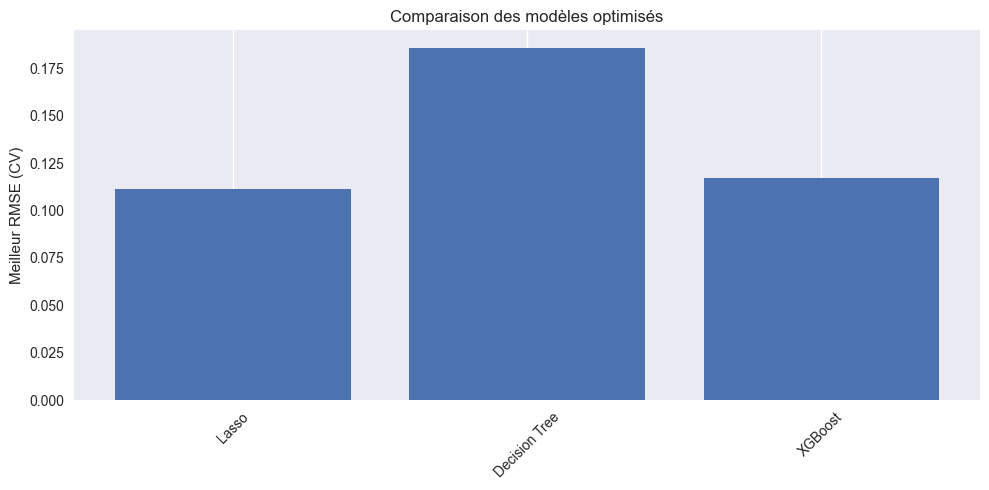

In [28]:
# ----------------------
# Exécution de l'optimisation et de l'évaluation des modèles
# ----------------------
model_configs = {
    #'Random Forest': random_forest_objective,
    'Lasso': lasso_objective,
    'Decision Tree': decision_tree_objective,
    'XGBoost': xgboost_objective
}

results = evaluate_and_optimize_models(model_configs, X_train, y_train, preprocessing_pipeline, n_trials=100)

# random_forest_best_params = results['Random Forest'][1]
lasso_best_params = results['Lasso'][1]
decision_tree_best_params = results['Decision Tree'][1]
xgboost_best_params = results['XGBoost'][1]

# random_forest_study = results['Random Forest'][2]
lasso_study = results['Lasso'][2]
decision_tree_study = results['Decision Tree'][2]
xgboost_study = results['XGBoost'][2]

In [29]:
# ----------------------
# Méthode d'évaluation finale avec une validation croisée de 10 "folds" 
# ----------------------
def evaluate_final_cv(model_name, model_class, best_params, preprocessing_pipeline, X, y, cv=10, scoring='neg_root_mean_squared_error'):
    model = model_class(**best_params, random_state=42)

    pipeline = Pipeline([
        ('preprocessing', preprocessing_pipeline),
        ('model', model)
    ])

    scores = cross_val_score(pipeline, X, y, cv=cv, scoring=scoring, n_jobs=-1)
    mean_rmse = -scores.mean()
    std_rmse = -scores.std()

    print(f"\nÉvaluation finale (cv 10) pour {model_name} :")
    print(f"✅ RMSE moyen : {mean_rmse:.5f}")
    print(f"📏 Écart-type : {std_rmse:.5f}")
    print("------------------------------------")
    
    return mean_rmse, std_rmse

# evaluate_final_cv("Random Forest", RandomForestRegressor, random_forest_best_params, preprocessing_pipeline, X_train, y_train)
evaluate_final_cv("Lasso", Lasso, lasso_best_params, preprocessing_pipeline, X_train, y_train)
evaluate_final_cv("Decision Tree", DecisionTreeRegressor, decision_tree_best_params, preprocessing_pipeline, X_train, y_train)
evaluate_final_cv("XGBoost", XGBRegressor, xgboost_best_params, preprocessing_pipeline, X_train, y_train)


Évaluation finale (cv 10) pour Lasso :
✅ RMSE moyen : 0.10971
📏 Écart-type : -0.01459
------------------------------------

Évaluation finale (cv 10) pour Decision Tree :
✅ RMSE moyen : 0.17878
📏 Écart-type : -0.01847
------------------------------------

Évaluation finale (cv 10) pour XGBoost :
✅ RMSE moyen : 0.11605
📏 Écart-type : -0.01630
------------------------------------


(np.float64(0.11605370715715002), np.float64(-0.016301062065957914))

A noter que les plages des hyperparamètres n'ont pas été sélectionnées au hasard. Elles ont été choisies à la suite d'analyse de graphiques Optuna `plot_slice`. Des itérations ont été réalisées mais pour éviter de surcharger ce document, nous n'avons inséré que le dernier graphique de chaque modèle (voir ci-dessous).

In [30]:
print("\nVisualisation des études Optuna pour Random Forest :")
#plot_slice(random_forest_study).show()

print("\nVisualisation des études Optuna pour Lasso :")
plot_slice(lasso_study).show()

print("\nVisualisation des études Optuna pour Decision Tree :")
plot_slice(decision_tree_study).show()

print("\nVisualisation des études Optuna pour XGBoost :")
plot_slice(xgboost_study).show()


Visualisation des études Optuna pour Random Forest :

Visualisation des études Optuna pour Lasso :



Visualisation des études Optuna pour Decision Tree :



Visualisation des études Optuna pour XGBoost :


Justification pour le Decision Tree :
 - Plusieurs essais des plages, ce qui a été fait après les résultats de slice plot:
 - Max_depth initialement large, resserrée entre 10–30
 - Max_features, log2 était sous-performant et a été retiré
 - Pour min_samples_leaf, les meilleures performances sont entre 10 et 15

Justification pour XGBoost : 
 - On a augmenté le nombre minimal d’arbres (n_estimators) car le modèle montrait de meilleures performances
 - On a limité la profondeur (max_depth) pour éviter la surcomplexité.
 - On a retiré les petites valeurs de min_child_weight et les grands gamma, qui tendaient à dégrader la performance 

# Séletion du modèle

Nous avons sélectionné le modèle XGBoost qui obtient un score de ...

In [33]:
xgboost_model = XGBRegressor(**xgboost_best_params, objective='reg:squarederror', random_state=42, n_jobs=-1)

model_pipeline = Pipeline([
    ('preprocessing_pipeline', preprocessing_pipeline),
    ('xgboost', xgboost_model)
    ])

model_pipeline.fit(X_train, y_train)

y_pred = model_pipeline.predict(X_test)

kaggle_submission = pd.DataFrame()
kaggle_submission['Id'] = X_test.index
kaggle_submission['SalePrice'] = np.expm1(y_pred)
kaggle_submission.to_csv('Data/xgboost.csv', index=False)

# Déploiement

In [34]:
# mlflow server --host 127.0.0.1 --port 8080

mlflow.set_tracking_uri(uri="http://127.0.0.1:8080")
mlflow.set_experiment("House_Price_Prediction")

2025/06/13 20:31:35 INFO mlflow.tracking.fluent: Experiment with name 'House_Price_Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='mlflow-artifacts:/243767882592717077', creation_time=1749839495703, experiment_id='243767882592717077', last_update_time=1749839495703, lifecycle_stage='active', name='House_Price_Prediction', tags={}>

In [35]:
with mlflow.start_run():
    # Log the hyperparameters
    mlflow.log_params(xgboost_best_params)

    # Log the loss metric
    mlflow.log_metric("accuracy", xgboost_study.best_value)

    # Set a tag that we can use to remind ourselves what this run was for
    mlflow.set_tag("Training Info", "XGBoost")

    # Infer the model signature
    signature = infer_signature(X_train, model_pipeline.predict(X_train))

    # Log the model
    model_info = mlflow.sklearn.log_model(
        sk_model=model_pipeline,
        signature=signature,
        input_example=X_train,
        registered_model_name="XGBoost_model",
        artifact_path="XGBoost_model"
    )

c:\DataScience\data-science-project\.venv\Lib\site-packages\mlflow\types\utils.py:452: UserWarning:

Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.



Successfully registered model 'XGBoost_model'.
2025/06/13 20:31:59 INFO mlflow.store.model_registry.abstract_store: Waiting up to 300 seconds for model version to finish creation. Model name: XGBoost_model, version 1


🏃 View run useful-auk-345 at: http://127.0.0.1:8080/#/experiments/243767882592717077/runs/263f5fccc58d4c968cc62710039fc4e7
🧪 View experiment at: http://127.0.0.1:8080/#/experiments/243767882592717077


Created version '1' of model 'XGBoost_model'.


# Conclusion

Ophélie

## Éthique